Exercise 11.1

In [85]:
def linear(x, m, q) :
    return m * x + q

In [86]:
from generator import generate_range, generate_TCL_ms
import numpy as np
m_true = 1.2
q_true = 1
epsilon_sigma = 0.3
x = np.arange(0.,10.,1)                                    #ma non erano casuali le x, generate_range( 0., 10., 10)'
y = np.zeros(10)
epsilons = generate_TCL_ms( 0., epsilon_sigma, 10)
for i in range(x.size):
    y[i] = linear(x[i], m_true, q_true) + epsilons[i]
print(x)
print(epsilons)
print(y)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[-0.4388113815701201, 0.4745261406643726, -0.353374842334184, 0.26735294890841266, -0.4906374176821746, 0.2221250873219535, -0.1475402633241497, 0.16155214375432175, -0.02723875297794709, -0.5933689228564418]
[ 0.56118862  2.67452614  3.04662516  4.86735295  5.30936258  7.22212509
  8.05245974  9.56155214 10.57276125 11.20663108]


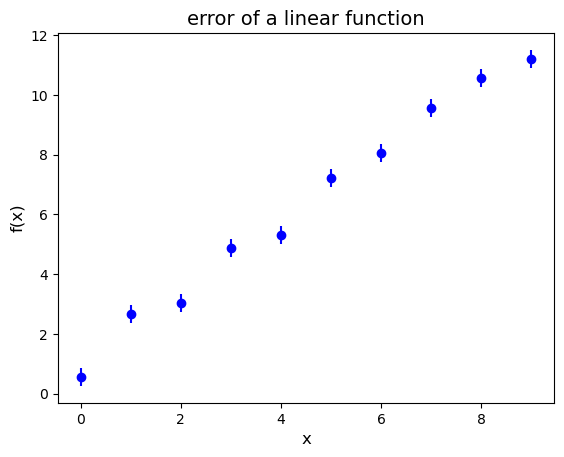

In [87]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.errorbar( x, y, xerr = 0, yerr = epsilon_sigma, color = 'b', linestyle = 'None', marker = 'o')
ax.set_title('error of a linear function', size = 14)
ax.set_ylabel('f(x)', size = 12)
ax.set_xlabel('x', size = 12)
plt.show()

Exercise 11.2

Use the iMinuit library to perform a fit on the simulated sample.
- Check if the fit was successful.
- Print the values of the determined parameters and their sigmas on the screen

In [88]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
least_squares = LeastSquares( x, y, epsilon_sigma, linear)
my_minuit = Minuit(least_squares, m = 0, q = 0)
my_minuit.migrad() 
my_minuit.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 13.27 (χ²/ndof = 1.7)      │              Nfcn = 40               │
│ EDM = 2.36e-20 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ m    │   1.183   │   0.033   │            │            │         │         │       │
│ 1 │ q    │   0.99    │   0.18    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────┐
│   │       m       q │
├───┼─────────────────┤
│ m │ 0.00109 -0.0049 │
│ q │ -0.0049  0.0311 │
└───┴─────────────────┘

In [89]:
# information about the function minimum can be directly accessed with Minuit.fmin
my_minuit.fmin

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 13.27 (χ²/ndof = 1.7)      │              Nfcn = 40               │
│ EDM = 2.36e-20 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘

In [90]:
fit_quality = my_minuit.valid
print('success of the fit: ', fit_quality)

success of the fit:  True


In [91]:
for par, val, err in zip( my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.3f} +- {err:.3f}')                          # .:f limita le cifre decimali
m_fit = my_minuit.values[0]
q_fit = my_minuit.values[1]
print(f'm = {m_fit} e q = {q_fit}')

m = 1.183 +- 0.033
q = 0.985 +- 0.176
m = 1.1826627010403215 e q = 0.9854763193076828


Exercise 11.3

- Calculate the value of Q_squared using the points and the fitted function obtained in the previous exercise.
- Compare the value obtained with iminuit with the calculated one.
- Print the value of the degrees of freedom of the fit.

In [92]:
Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

value of the fit Q-squared 13.271166644597365
value of the number of degrees of freedom 8.0


In [93]:
Q_squared_calculated = 0.
for i in range (x.size):
    Q_squared_calculated = Q_squared_calculated + ((y[i] - linear(x[i], m_fit, q_fit))/epsilon_sigma)**2
print('Q calculated = ',Q_squared_calculated)

Q calculated =  13.271166644597365


In [104]:
from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

associated p-value:  0.9736213722378818


In [105]:
print(my_minuit.covariance)

┌───┬─────────────────┐
│   │       m       q │
├───┼─────────────────┤
│ m │ 0.00109 -0.0049 │
│ q │ -0.0049  0.0311 │
└───┴─────────────────┘


In [106]:
print('variance of the first parameter(m) : ', my_minuit.covariance[0][0])
print('variance of the second parameter(q) : ', my_minuit.covariance[1][1])
print('covariance of the parameters : ', my_minuit.covariance[0][1])

variance of the first parameter(m) :  0.001090907826483458
variance of the second parameter(q) :  0.031090877853701356
covariance of the parameters :  -0.004909084713407048


Exercise 11.4
- Using the toy experiments technique, generate 10,000 fit experiments with the model studied in the previous exercises and fill a histogram with the obtained values of Q_squared.
- Compare the expected value of Q_squared obtained from the toy experiments with the degrees of freedom of the problem.

In [94]:
from math import floor
N_toys = 10000
x = np.arange(0.,10.,1)
Q_squared = []
for i in range(N_toys):
    y = np.zeros(10)
    epsilons = generate_TCL_ms( 0., epsilon_sigma, 10)
    for i in range(x.size):
        y[i] = linear(x[i], m_true, q_true) + epsilons[i]
    least_squares = LeastSquares( x, y, epsilon_sigma, linear)
    my_minuit = Minuit(least_squares, m = 0, q = 0)
    my_minuit.migrad() 
    my_minuit.hesse()
    if my_minuit.valid :
        Q_squared.append(my_minuit.fval)

In [95]:
xmin = min(Q_squared)
xmax = max(Q_squared)
Nbins = floor(len(Q_squared)/10.)
bins_edges = np.linspace( xmin, xmax, Nbins + 1)

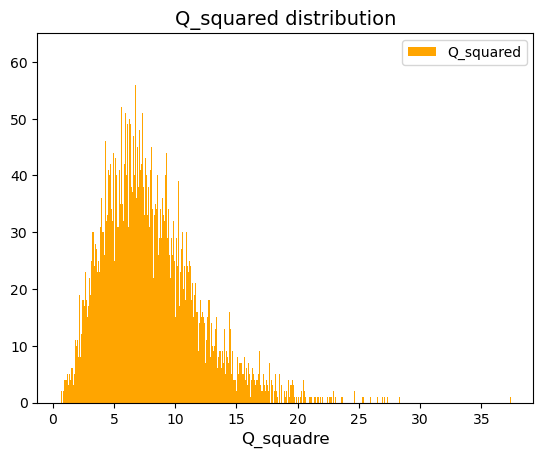

In [96]:
fig, ax = plt.subplots()
ax.hist(Q_squared, bins = bins_edges, color = 'orange', label = 'Q_squared')
ax.set_title('Q_squared distribution', size = 14)
ax.set_xlabel('Q_squadre', size = 12)
ax.legend()
plt.show()

In [97]:
from stats import stats
Q_squared_expected = stats(Q_squared)
print('Q_squared expected value : ', Q_squared_expected.mean() )

Q_squared expected value :  8.029947222249026


Exercise 11.5
- Modify the previous program by deliberately changing the experimental uncertainty associated with the points
in the sample and verify that it’s possible to recover the uncertainty used in generating the points through the expected value of the variable Q_squared

In [108]:
from math import sqrt
N_toys = 10000
x = np.arange(0.,10.,1)
new_epsilon = 0.6 * epsilon_sigma
Q_squared = []
for i in range(N_toys):
    epsilons = generate_TCL_ms( 0., new_epsilon, 10)
    y = np.zeros(10)
    for i in range(x.size):
        y[i] = linear(x[i], m_true, q_true) + epsilons[i]
    least_squares = LeastSquares( x, y, epsilon_sigma, linear)                     #incertezza uguale al modello precedente
    my_minuit = Minuit(least_squares, m = 0, q = 0)
    my_minuit.migrad() 
    my_minuit.hesse()
    if my_minuit.valid :
        Q_squared.append(my_minuit.fval)
my_squared = stats(Q_squared)
print('Expected value of Q_squared : ', my_squared.mean() )
print('Factor changing sigma : ', sqrt(my_squared.mean()/N_dof) )
print('Sigma : ', new_epsilon / sqrt (my_squared.mean () / N_dof) )

Expected value of Q_squared :  2.9134102296933495
Factor changing sigma :  0.6034701970368286
Sigma :  0.2982748789979018


Exercise 11.7
- Repeat the fitting exercise for a parabolic trend.

In [107]:
def func(x,a,b,c) :
    return a*x**2 + b*x + c

In [119]:
a_true = 1
b_true = 2.3
c_true = 3.1
epsilon = 4.3
x_coord = np.arange(0,10,1)
y_coord = np.zeros(10)
epsilon_s = generate_TCL_ms(0., epsilon, 10)
for i in range(x.size) :
    y_coord[i] = func(x_coord[i], a_true, b_true, c_true) + epsilon_s[i]

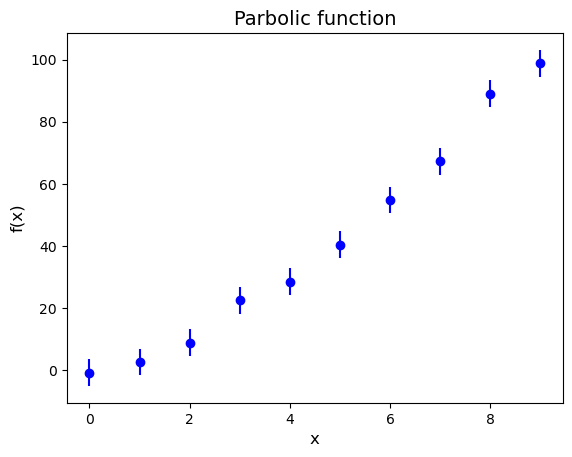

In [120]:
fig, ax = plt.subplots()
plt.errorbar( x_coord, y_coord, xerr = 0.0, yerr = epsilon, linestyle = 'None', marker = 'o', color = 'b')
ax.set_title('Parbolic function', size = 14)
ax.set_ylabel('f(x)', size = 12)
ax.set_xlabel('x', size = 12)
plt.show()

In [122]:
least_squares = LeastSquares( x_coord, y_coord, epsilon, func)
my_minuit = Minuit(least_squares, a = 0, b = 0, c = 0)
my_minuit.migrad()
my_minuit.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.652 (χ²/ndof = 0.4)      │              Nfcn = 72               │
│ EDM = 2.3e-18 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.71    │   0.19    │            │            │         │         │       │
│ 1 │ b    │    5.1    │    1.7    │            │            │         │         │       │
│ 2 │ c    │   -2.1    │    3.4    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────────────────┐
│   │      a      b      c │
├───┼──────────────────────┤
│ a │  0.035 -0.315  0.420 │
│ b │ -0.315   3.06   -4.8 │
│ c │  0.420   -4.8   11.4 │
└───┴──────────────────────┘

In [ ]:
for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}')
    
m_fit = my_minuit.values[0]
q_fit = my_minuit.values[1]  

In [126]:
print(my_minuit.covariance)

┌───┬──────────────────────┐
│   │      a      b      c │
├───┼──────────────────────┤
│ a │  0.035 -0.315  0.420 │
│ b │ -0.315   3.06   -4.8 │
│ c │  0.420   -4.8   11.4 │
└───┴──────────────────────┘


In [128]:
print('Variance first parameter (a) : ', my_minuit.covariance[0][0])
print('Variance second parameter (b) : ', my_minuit.covariance[1][1])
print('Variance third parameter (c) : ', my_minuit.covariance[2][2])

Variance first parameter (a) :  0.035017598272210605
Variance second parameter (b) :  3.060535845346281
Variance third parameter (c) :  11.429920674417023


In [123]:
is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

success of the fit:  True


In [125]:
Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

value of the fit Q-squared 2.6517829587552675
value of the number of degrees of freedom 7.0
associated p-value:  0.9152407905441153
